# 🧠 Alzheimer's MRI Classification with Swin Transformer

This notebook classifies brain MRI scans into 4 categories of cognitive impairment using **Microsoft's Swin Transformer** architecture:
- **Mild Demented** | **Moderate Demented** | **Non Demented** | **Very Mild Demented**

**Model**: `microsoft/swin-base-patch4-window7-224` from Hugging Face

**Pipeline:**
1. Load & explore data from Hugging Face
2. Set up Swin Transformer with transfer learning
3. Apply data augmentation (including MONAI transforms)
4. Handle class imbalance with weighted loss & balanced sampling
5. Train and evaluate with comprehensive metrics
6. Visualize attention maps

In [1]:
# ====== IMPORTS & DEVICE SETUP ======
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, 
    ConfusionMatrixDisplay, balanced_accuracy_score, f1_score, 
    matthews_corrcoef, cohen_kappa_score, precision_recall_fscore_support,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from torchvision import transforms
from datasets import load_dataset
from transformers import AutoImageProcessor, SwinForImageClassification
from collections import Counter
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# MONAI for advanced augmentation
import monai.transforms as mt

torch.backends.cudnn.benchmark = True
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device | PyTorch {torch.__version__}")

/home/paris/miniconda3/envs/jupyter/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda device | PyTorch 2.9.0+rocm6.4


## 1. Load & Explore Data

Loaded 5120 samples with 4 classes


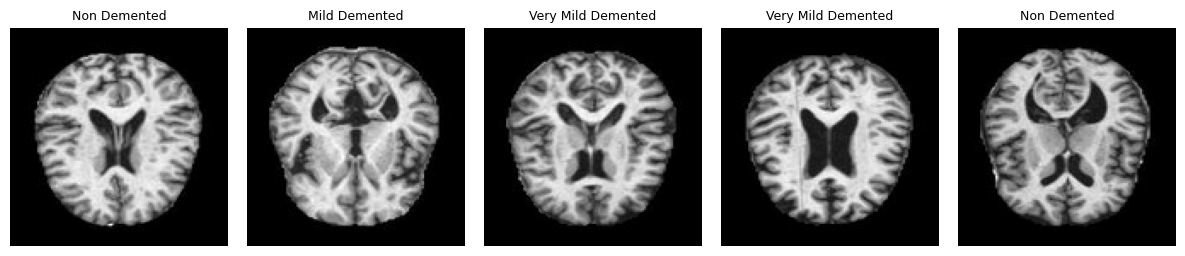

In [2]:
# Load dataset & define label mapping
dataset = load_dataset('Falah/Alzheimer_MRI', split='train')
LABELS = {0: "Mild Demented", 1: "Moderate Demented", 2: "Non Demented", 3: "Very Mild Demented"}
NUM_CLASSES = len(LABELS)
print(f"Loaded {len(dataset)} samples with {NUM_CLASSES} classes")

# Show sample images
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(dataset[i]['image'], cmap='gray')
    ax.set_title(LABELS[dataset[i]['label']], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

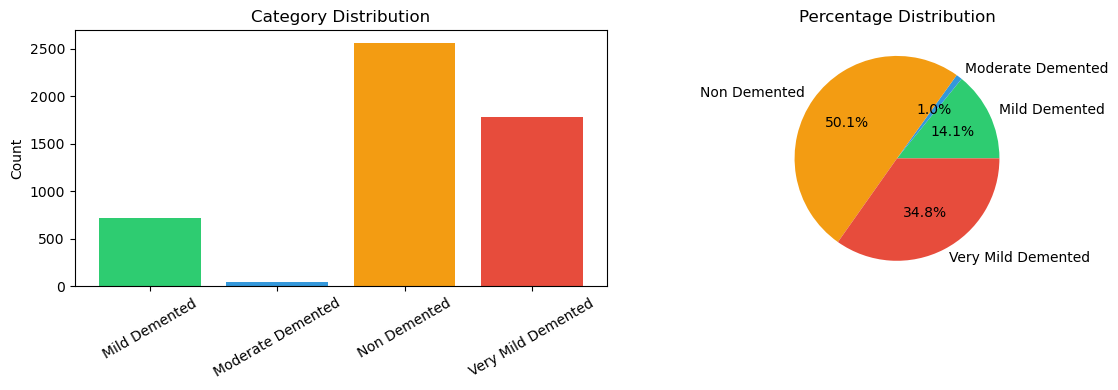


Class Distribution:
--------------------------------------------------
  Mild Demented       :   724 samples ( 14.1%)
  Moderate Demented   :    49 samples (  1.0%)
  Non Demented        :  2566 samples ( 50.1%)
  Very Mild Demented  :  1781 samples ( 34.8%)


In [3]:
# Class distribution analysis
counts = {l: sum(1 for ex in dataset if ex['label'] == l) for l in range(NUM_CLASSES)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

ax1.bar([LABELS[i] for i in range(NUM_CLASSES)], [counts[i] for i in range(NUM_CLASSES)], color=colors)
ax1.set_ylabel('Count')
ax1.set_title('Category Distribution')
ax1.tick_params(axis='x', rotation=30)

ax2.pie([counts[i] for i in range(NUM_CLASSES)], labels=[LABELS[i] for i in range(NUM_CLASSES)], 
        autopct='%1.1f%%', colors=colors)
ax2.set_title('Percentage Distribution')

plt.tight_layout()
plt.show()

# Print imbalance analysis
print("\nClass Distribution:")
print("-" * 50)
for cls_id in range(NUM_CLASSES):
    pct = 100 * counts[cls_id] / len(dataset)
    print(f"  {LABELS[cls_id]:20s}: {counts[cls_id]:5d} samples ({pct:5.1f}%)")

## 2. Setup Swin Transformer Model

We use Microsoft's **Swin-Base** pretrained on ImageNet-21k, fine-tuned for our 4-class classification task.

Key considerations:
- Swin expects **224x224 RGB images** - we'll convert grayscale MRI to RGB
- Using the model's built-in image processor for proper normalization
- Freezing early layers, fine-tuning later layers + classifier head

In [4]:
# Load Swin Transformer model and image processor
MODEL_NAME = "microsoft/swin-base-patch4-window7-224"

print(f"Loading {MODEL_NAME}...")
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = SwinForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,  # Allow replacing the classifier head
    id2label=LABELS,
    label2id={v: k for k, v in LABELS.items()}
)

# Move model to device
model = model.to(device)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel loaded successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading microsoft/swin-base-patch4-window7-224...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-base-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 1024]) in the checkpoint and torch.Size([4, 1024]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model loaded successfully!
Total parameters: 86,747,324
Trainable parameters: 86,747,324


In [5]:
# Fine-tuning strategy: Freeze early layers, train later layers + head
def setup_fine_tuning(model, freeze_ratio=0.7):
    """
    Freeze early layers of Swin Transformer for transfer learning.
    freeze_ratio: Proportion of layers to freeze (0.7 = freeze first 70% of layers)
    """
    # Get all named parameters
    all_params = list(model.named_parameters())
    n_params = len(all_params)
    freeze_until = int(n_params * freeze_ratio)
    
    # Freeze early parameters
    for i, (name, param) in enumerate(all_params):
        if i < freeze_until:
            param.requires_grad = False
        else:
            param.requires_grad = True
    
    # Always train the classifier head
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Fine-tuning setup: {trainable:,} / {total:,} parameters trainable ({100*trainable/total:.1f}%)")
    
    return model

# Apply fine-tuning strategy
model = setup_fine_tuning(model, freeze_ratio=0.6)

Fine-tuning setup: 52,022,324 / 86,747,324 parameters trainable (60.0%)


## 3. Dataset & DataLoaders with Augmentation

Custom PyTorch Dataset that:
- Converts grayscale MRI to RGB (required by Swin)
- Resizes to 224x224 (Swin's expected input size)
- Applies MONAI augmentation with stronger transforms for minority classes
- Uses Hugging Face's image processor for proper normalization

In [6]:
class SwinAlzheimersDataset(Dataset):
    """
    PyTorch Dataset for Alzheimer's MRI images optimized for Swin Transformer.
    
    - Converts grayscale to RGB
    - Resizes to 224x224
    - Applies MONAI augmentation with stronger transforms for minority classes
    - Uses HuggingFace image processor for Swin normalization
    """
    def __init__(self, hf_dataset, indices, image_processor, class_counts=None, 
                 augment=True, minority_threshold=0.15):
        self.data = hf_dataset
        self.indices = indices
        self.image_processor = image_processor
        self.augment = augment
        
        # Identify minority classes
        if class_counts:
            total = sum(class_counts.values())
            self.minority_classes = {
                c for c, count in class_counts.items() 
                if count / total < minority_threshold
            }
        else:
            self.minority_classes = set()
        
        # MONAI augmentation for minority classes (aggressive)
        self.monai_minority = mt.Compose([
            mt.RandFlip(prob=0.5, spatial_axis=1),
            mt.RandRotate(prob=0.8, range_x=0.35),  # ~20 degrees
            mt.RandZoom(prob=0.5, min_zoom=0.85, max_zoom=1.15),
            mt.RandGaussianNoise(prob=0.3, mean=0.0, std=0.05),
            mt.RandAdjustContrast(prob=0.3, gamma=(0.8, 1.2)),
            mt.RandGaussianSmooth(prob=0.2, sigma_x=(0.25, 0.75)),
            mt.RandShiftIntensity(prob=0.3, offsets=0.1),
        ])
        
        # Standard augmentation for majority classes
        self.monai_standard = mt.Compose([
            mt.RandFlip(prob=0.5, spatial_axis=1),
            mt.RandRotate(prob=0.5, range_x=0.26),  # ~15 degrees
            mt.RandZoom(prob=0.3, min_zoom=0.9, max_zoom=1.1),
        ])
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img = self.data[real_idx]['image']
        label = self.data[real_idx]['label']
        
        # Convert to numpy array and normalize to [0, 1]
        img_np = np.array(img, dtype=np.float32) / 255.0
        
        # Apply MONAI augmentation (before RGB conversion)
        if self.augment:
            img_tensor = torch.tensor(img_np).unsqueeze(0)  # (1, H, W)
            if label in self.minority_classes:
                img_tensor = self.monai_minority(img_tensor)
            else:
                img_tensor = self.monai_standard(img_tensor)
            img_np = img_tensor.squeeze(0).numpy()
        
        # Ensure values are clipped to valid range
        img_np = np.clip(img_np, 0, 1)
        
        # Convert grayscale to RGB by stacking 3 channels
        # Scale back to 0-255 for image processor
        img_rgb = np.stack([img_np * 255] * 3, axis=-1).astype(np.uint8)
        
        # Use Swin's image processor for resizing and normalization
        # Returns dict with 'pixel_values' tensor
        processed = self.image_processor(images=img_rgb, return_tensors="pt")
        pixel_values = processed['pixel_values'].squeeze(0)  # Remove batch dim
        
        return pixel_values, torch.tensor(label, dtype=torch.long)


class SwinAlzheimersDatasetNoAug(Dataset):
    """
    Dataset without augmentation (for validation/test).
    """
    def __init__(self, hf_dataset, indices, image_processor):
        self.data = hf_dataset
        self.indices = indices
        self.image_processor = image_processor
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img = self.data[real_idx]['image']
        label = self.data[real_idx]['label']
        
        # Convert to numpy and then to RGB
        img_np = np.array(img, dtype=np.uint8)
        img_rgb = np.stack([img_np] * 3, axis=-1)
        
        # Process for Swin
        processed = self.image_processor(images=img_rgb, return_tensors="pt")
        pixel_values = processed['pixel_values'].squeeze(0)
        
        return pixel_values, torch.tensor(label, dtype=torch.long)

In [7]:
# Stratified train/val split (80/20)
all_labels = [ex['label'] for ex in dataset]
train_idx, val_idx = train_test_split(
    np.arange(len(dataset)), 
    test_size=0.2, 
    stratify=all_labels, 
    random_state=42
)

# Compute class counts for training set
train_labels = [dataset[idx]['label'] for idx in train_idx]
class_counts = Counter(train_labels)

print("Training Set Class Distribution:")
print("-" * 50)
for cls_id in sorted(class_counts.keys()):
    count = class_counts[cls_id]
    pct = 100 * count / len(train_labels)
    print(f"  {LABELS[cls_id]:20s}: {count:5d} samples ({pct:5.1f}%)")

# Identify imbalance
min_class = min(class_counts, key=class_counts.get)
max_class = max(class_counts, key=class_counts.get)
imbalance_ratio = class_counts[max_class] / class_counts[min_class]
print(f"\nImbalance ratio: {imbalance_ratio:.2f}x")

# Create datasets
train_dataset = SwinAlzheimersDataset(
    dataset, train_idx, image_processor, 
    class_counts=class_counts, augment=True, minority_threshold=0.15
)
val_dataset = SwinAlzheimersDatasetNoAug(dataset, val_idx, image_processor)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)}")

Training Set Class Distribution:
--------------------------------------------------
  Mild Demented       :   579 samples ( 14.1%)
  Moderate Demented   :    39 samples (  1.0%)
  Non Demented        :  2053 samples ( 50.1%)
  Very Mild Demented  :  1425 samples ( 34.8%)

Imbalance ratio: 52.64x

Train: 4096 | Val: 1024


In [8]:
# Compute class weights for weighted loss (inverse frequency)
total_train = len(train_labels)
n_classes = len(class_counts)
class_weights = torch.tensor([
    total_train / (n_classes * class_counts[i]) 
    for i in range(n_classes)
], dtype=torch.float32).to(device)

print("Class weights for weighted loss:")
for i, w in enumerate(class_weights):
    print(f"  {LABELS[i]:20s}: {w:.4f}")

# Create balanced sampler for oversampling minority classes
def create_balanced_sampler(labels):
    """WeightedRandomSampler to oversample minority classes."""
    class_counts_local = Counter(labels)
    n_samples = len(labels)
    class_weights_local = {cls: n_samples / count for cls, count in class_counts_local.items()}
    sample_weights = [class_weights_local[label] for label in labels]
    return WeightedRandomSampler(weights=sample_weights, num_samples=n_samples, replacement=True)

balanced_sampler = create_balanced_sampler(train_labels)
print("\n✓ Balanced sampler created for oversampling minority classes")

Class weights for weighted loss:
  Mild Demented       : 1.7686
  Moderate Demented   : 26.2564
  Non Demented        : 0.4988
  Very Mild Demented  : 0.7186

✓ Balanced sampler created for oversampling minority classes


In [9]:
# Create DataLoaders
BATCH_SIZE = 16  # Smaller batch size for Swin (large model)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=balanced_sampler,  # Use balanced sampling
    pin_memory=(device == 'cuda'),
    num_workers=2
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    pin_memory=(device == 'cuda'),
    num_workers=2
)

print(f"DataLoaders created: Batch size = {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

DataLoaders created: Batch size = 16
  Train batches: 256
  Val batches: 64


## 4. Training & Evaluation Functions

Comprehensive metrics including:
- **Accuracy** & **Balanced Accuracy** (handles imbalance)
- **F1-Score** (Macro & Weighted)
- **MCC** (Matthews Correlation Coefficient)
- **Cohen's Kappa**
- **Per-class Precision, Recall, F1**

In [10]:
def compute_all_metrics(y_true, y_pred, y_proba=None, class_names=None):
    """
    Compute comprehensive classification metrics.
    """
    metrics = {}
    
    # Overall metrics
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
    metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro')
    metrics['f1_weighted'] = f1_score(y_true, y_pred, average='weighted')
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)
    metrics['kappa'] = cohen_kappa_score(y_true, y_pred)
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    if class_names is None:
        class_names = [f'Class_{i}' for i in range(len(precision))]
    
    metrics['per_class'] = {}
    for i, name in enumerate(class_names):
        metrics['per_class'][name] = {
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i],
            'support': int(support[i])
        }
    
    # ROC-AUC if probabilities available
    if y_proba is not None:
        try:
            metrics['roc_auc_ovr'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except:
            metrics['roc_auc_ovr'] = None
    
    return metrics


def predict_with_proba(model, loader):
    """Run inference and return predictions, true labels, and probabilities."""
    model.eval()
    preds, labels, probas = [], [], []
    
    with torch.no_grad():
        for pixel_values, lbls in tqdm.tqdm(loader, desc='Predicting', leave=False):
            pixel_values = pixel_values.to(device)
            outputs = model(pixel_values)
            logits = outputs.logits
            probs = F.softmax(logits, dim=1)
            
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
            probas.extend(probs.cpu().numpy())
    
    return np.array(preds), np.array(labels), np.array(probas)

In [11]:
def train_swin_model(model, train_loader, val_loader, optimizer, criterion, 
                     scheduler=None, epochs=10, early_stopping_patience=5):
    """
    Training loop for Swin Transformer with early stopping.
    Returns best model state and training history.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        # === Training Phase ===
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        pbar = tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False)
        for pixel_values, labels in pbar:
            pixel_values = pixel_values.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(pixel_values)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            train_correct += (outputs.logits.argmax(1) == labels).sum().item()
            train_total += labels.size(0)
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        
        # === Validation Phase ===
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for pixel_values, labels in tqdm.tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]', leave=False):
                pixel_values = pixel_values.to(device)
                labels = labels.to(device)
                
                outputs = model(pixel_values)
                loss = criterion(outputs.logits, labels)
                
                val_loss += loss.item()
                val_correct += (outputs.logits.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        # Learning rate scheduler step
        if scheduler:
            scheduler.step(avg_val_loss)
        
        # Check for best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict().copy()
            patience_counter = 0
            print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} ⭐ (Best)")
        else:
            patience_counter += 1
            print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")
        
        # Early stopping
        if patience_counter >= early_stopping_patience:
            print(f"\n⚠️ Early stopping triggered after {epoch+1} epochs")
            break
    
    # Load best model state
    if best_state:
        model.load_state_dict(best_state)
        print(f"\n✓ Loaded best model with Val Acc: {best_val_acc:.4f}")
    
    return model, history

## 5. Train Swin Transformer

Training with:
- **Class-weighted CrossEntropyLoss** to handle imbalance
- **AdamW optimizer** with weight decay for regularization
- **ReduceLROnPlateau scheduler** to reduce LR when validation loss plateaus
- **Early stopping** to prevent overfitting

In [13]:
# Training configuration
LEARNING_RATE = 2e-5  # Lower LR for fine-tuning pretrained model
WEIGHT_DECAY = 0.01
EPOCHS = 15
EARLY_STOPPING_PATIENCE = 5

# Optimizer - use different LR for classifier head vs backbone
# Higher LR for classifier (new layers), lower for backbone (pretrained)
classifier_params = list(model.classifier.parameters())
backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n and p.requires_grad]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LEARNING_RATE},
    {'params': classifier_params, 'lr': LEARNING_RATE * 10}  # 10x LR for classifier
], weight_decay=WEIGHT_DECAY)

# Criterion with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print("Training Configuration:")
print(f"  Learning Rate (backbone): {LEARNING_RATE}")
print(f"  Learning Rate (classifier): {LEARNING_RATE * 10}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Epochs: {EPOCHS}")
print(f"  Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

Training Configuration:
  Learning Rate (backbone): 2e-05
  Learning Rate (classifier): 0.0002
  Weight Decay: 0.01
  Epochs: 15
  Early Stopping Patience: 5


In [14]:
# Train the model
print("=" * 60)
print("Training Swin Transformer for Alzheimer's Classification")
print("=" * 60)

model, history = train_swin_model(
    model, train_loader, val_loader, 
    optimizer, criterion, scheduler,
    epochs=EPOCHS, 
    early_stopping_patience=EARLY_STOPPING_PATIENCE
)

Training Swin Transformer for Alzheimer's Classification


Epoch 1: Train Acc=0.5388 | Val Acc=0.5557 ⭐ (Best)


Epoch 2: Train Acc=0.7114 | Val Acc=0.5020


Epoch 3: Train Acc=0.7515 | Val Acc=0.6074 ⭐ (Best)


Epoch 4: Train Acc=0.7688 | Val Acc=0.5996


...

Epoch 11: Train Acc=0.9075 | Val Acc=0.7939 ⭐ (Best)


Epoch 12: Train Acc=0.9114 | Val Acc=0.8291 ⭐ (Best)


Epoch 13: Train Acc=0.9158 | Val Acc=0.8350 ⭐ (Best)


Epoch 14: Train Acc=0.9277 | Val Acc=0.8379 ⭐ (Best)


Epoch 15: Train Acc=0.9338 | Val Acc=0.8760 ⭐ (Best)

✓ Loaded best model with Val Acc: 0.8760


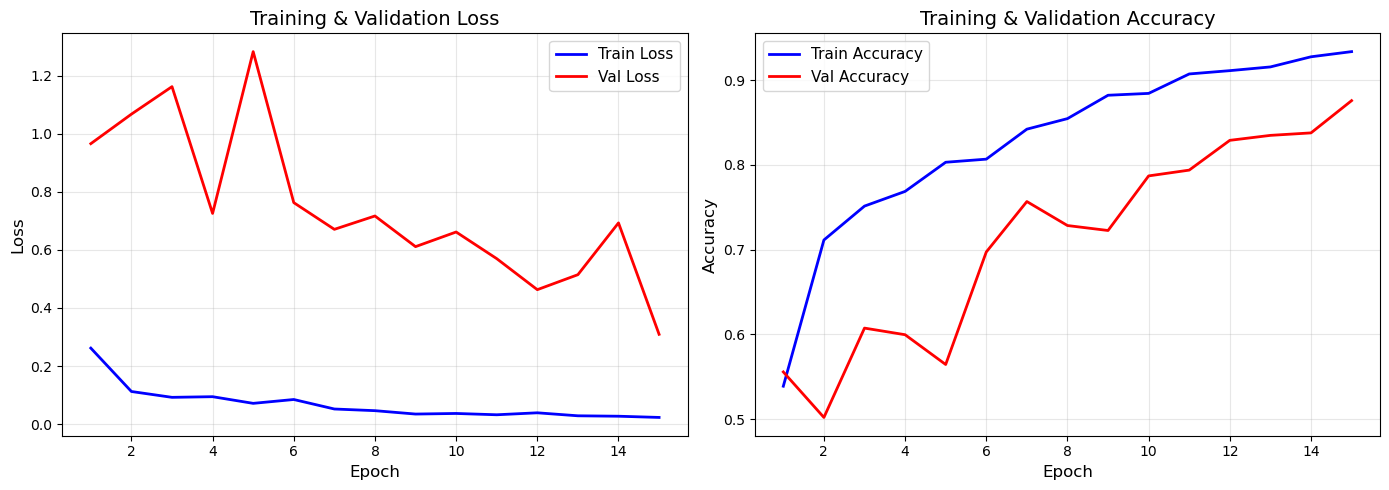


Best Validation Accuracy: 0.8760


In [15]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training & Validation Accuracy', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Validation Accuracy: {max(history['val_acc']):.4f}")

## 6. Model Evaluation

Comprehensive evaluation with multiple metrics to assess performance on imbalanced classes.

In [16]:
# Get predictions on validation set
preds, labels, probas = predict_with_proba(model, val_loader)

# Compute comprehensive metrics
metrics = compute_all_metrics(labels, preds, probas, list(LABELS.values()))

# Display results
print("=" * 70)
print("SWIN TRANSFORMER - EVALUATION RESULTS")
print("=" * 70)

print("\n📊 Overall Metrics:")
print("-" * 50)
print(f"  Accuracy:          {metrics['accuracy']:.4f}")
print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
print(f"  F1 (Macro):        {metrics['f1_macro']:.4f}")
print(f"  F1 (Weighted):     {metrics['f1_weighted']:.4f}")
print(f"  MCC:               {metrics['mcc']:.4f}")
print(f"  Cohen's Kappa:     {metrics['kappa']:.4f}")
if metrics.get('roc_auc_ovr'):
    print(f"  ROC-AUC (OvR):     {metrics['roc_auc_ovr']:.4f}")

print("\n📋 Classification Report:")
print("-" * 50)
print(classification_report(labels, preds, target_names=list(LABELS.values()), digits=4))

SWIN TRANSFORMER - EVALUATION RESULTS

📊 Overall Metrics:
--------------------------------------------------
  Accuracy:          0.8760
  Balanced Accuracy: 0.9044
  F1 (Macro):        0.8916
  F1 (Weighted):     0.8768
  MCC:               0.7996
  Cohen's Kappa:     0.7977
  ROC-AUC (OvR):     0.9773

📋 Classification Report:
--------------------------------------------------
                    precision    recall  f1-score   support

     Mild Demented     0.8794    0.8552    0.8671       145
 Moderate Demented     0.9091    1.0000    0.9524        10
      Non Demented     0.9307    0.8635    0.8959       513
Very Mild Demented     0.8081    0.8989    0.8511       356

          accuracy                         0.8760      1024
         macro avg     0.8818    0.9044    0.8916      1024
      weighted avg     0.8806    0.8760    0.8768      1024



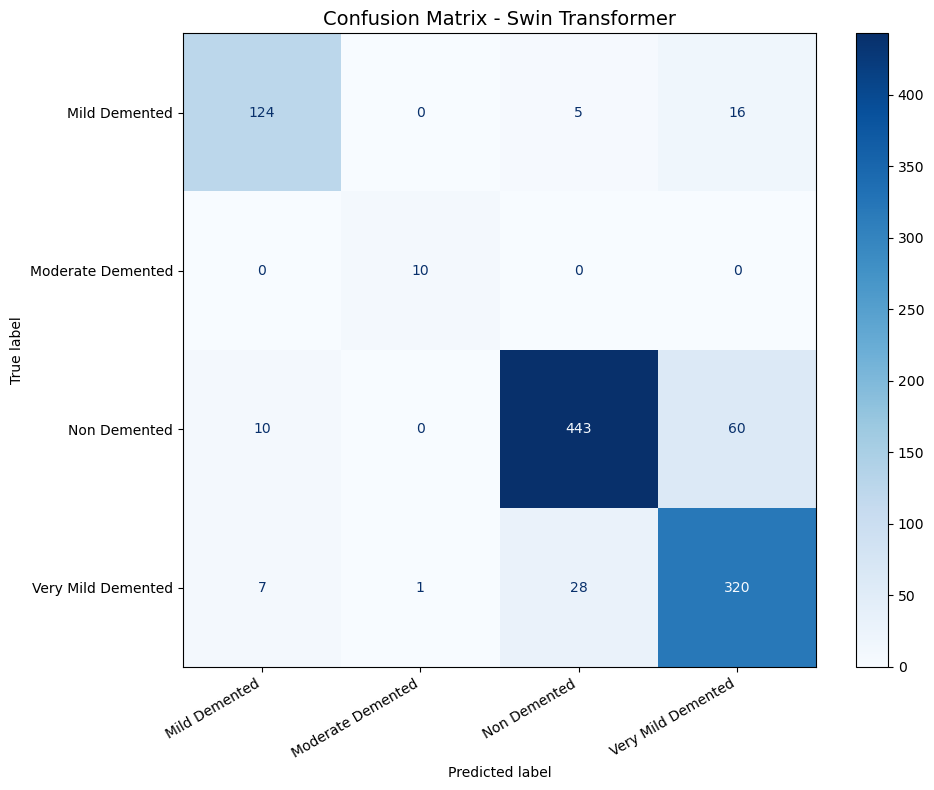


📈 Per-Class Performance:
----------------------------------------------------------------------
             Class  Precision   Recall  F1-Score  Support
     Mild Demented   0.879433 0.855172  0.867133      145
 Moderate Demented   0.909091 1.000000  0.952381       10
      Non Demented   0.930672 0.863548  0.895854      513
Very Mild Demented   0.808081 0.898876  0.851064      356


In [17]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LABELS.values()))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Swin Transformer', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Per-class metrics table
print("\n📈 Per-Class Performance:")
print("-" * 70)
per_class_df = pd.DataFrame({
    'Class': list(LABELS.values()),
    'Precision': [metrics['per_class'][c]['precision'] for c in LABELS.values()],
    'Recall': [metrics['per_class'][c]['recall'] for c in LABELS.values()],
    'F1-Score': [metrics['per_class'][c]['f1'] for c in LABELS.values()],
    'Support': [metrics['per_class'][c]['support'] for c in LABELS.values()]
})
print(per_class_df.to_string(index=False))

## 7. Attention Visualization

Visualize the Swin Transformer's attention patterns to understand which regions of the MRI the model focuses on.

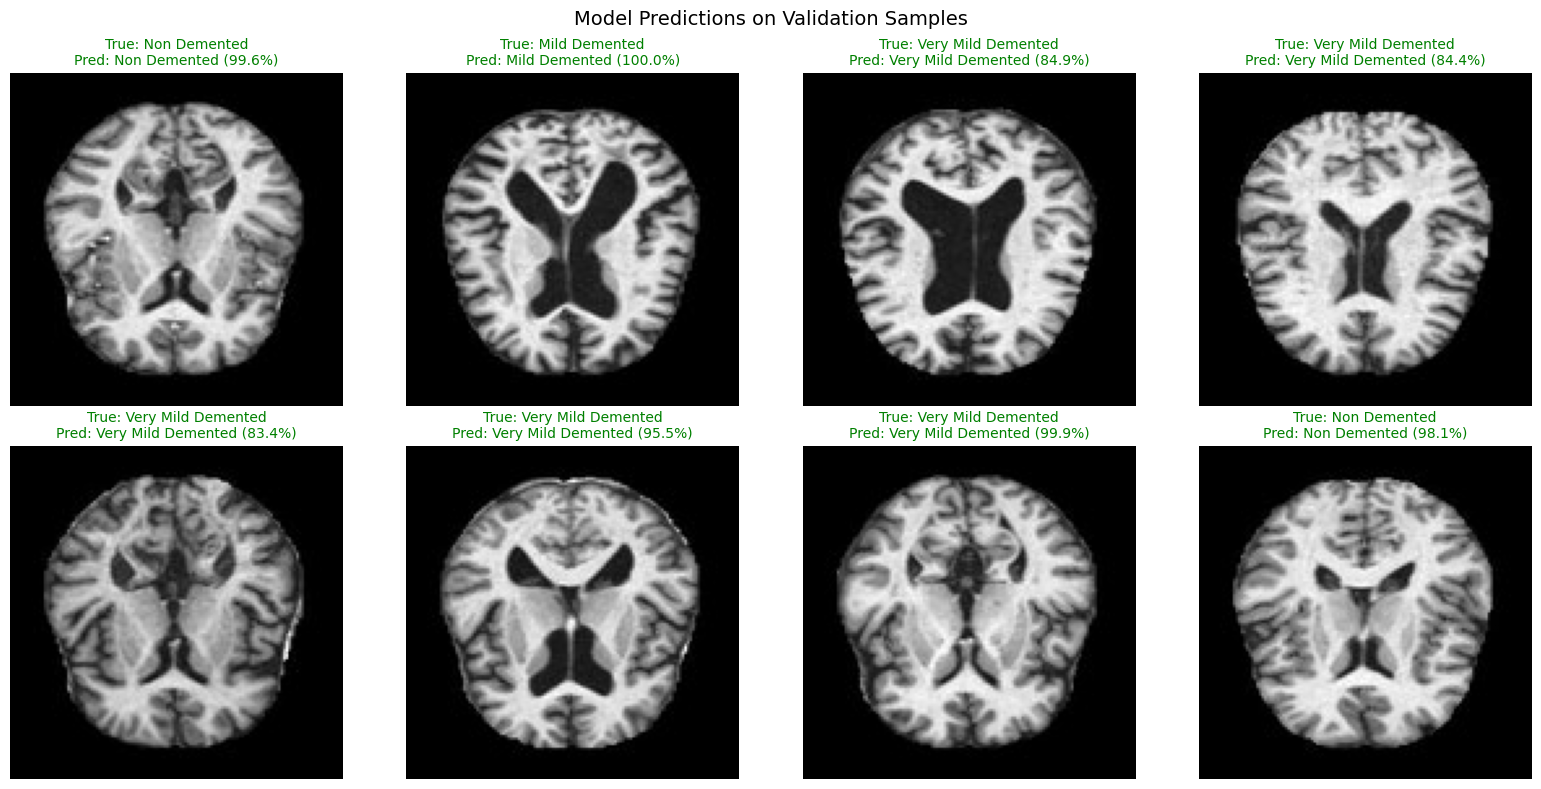

In [18]:
def visualize_predictions(model, dataset, indices, n_samples=8):
    """
    Visualize model predictions on sample images with confidence scores.
    """
    model.eval()
    
    # Get random samples
    sample_indices = np.random.choice(len(indices), min(n_samples, len(indices)), replace=False)
    
    n_cols = 4
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_samples > 1 else [axes]
    
    for i, sample_idx in enumerate(sample_indices):
        real_idx = indices[sample_idx]
        img = dataset[real_idx]['image']
        true_label = dataset[real_idx]['label']
        
        # Prepare image for model
        img_np = np.array(img, dtype=np.uint8)
        img_rgb = np.stack([img_np] * 3, axis=-1)
        processed = image_processor(images=img_rgb, return_tensors="pt")
        pixel_values = processed['pixel_values'].to(device)
        
        # Get prediction
        with torch.no_grad():
            outputs = model(pixel_values)
            probs = F.softmax(outputs.logits, dim=1)[0]
            pred_label = probs.argmax().item()
            confidence = probs[pred_label].item()
        
        # Plot
        ax = axes[i]
        ax.imshow(img_np, cmap='gray')
        
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(
            f"True: {LABELS[true_label]}\nPred: {LABELS[pred_label]} ({confidence:.1%})",
            fontsize=10, color=color
        )
        ax.axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Model Predictions on Validation Samples', fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize predictions
visualize_predictions(model, dataset, val_idx, n_samples=8)

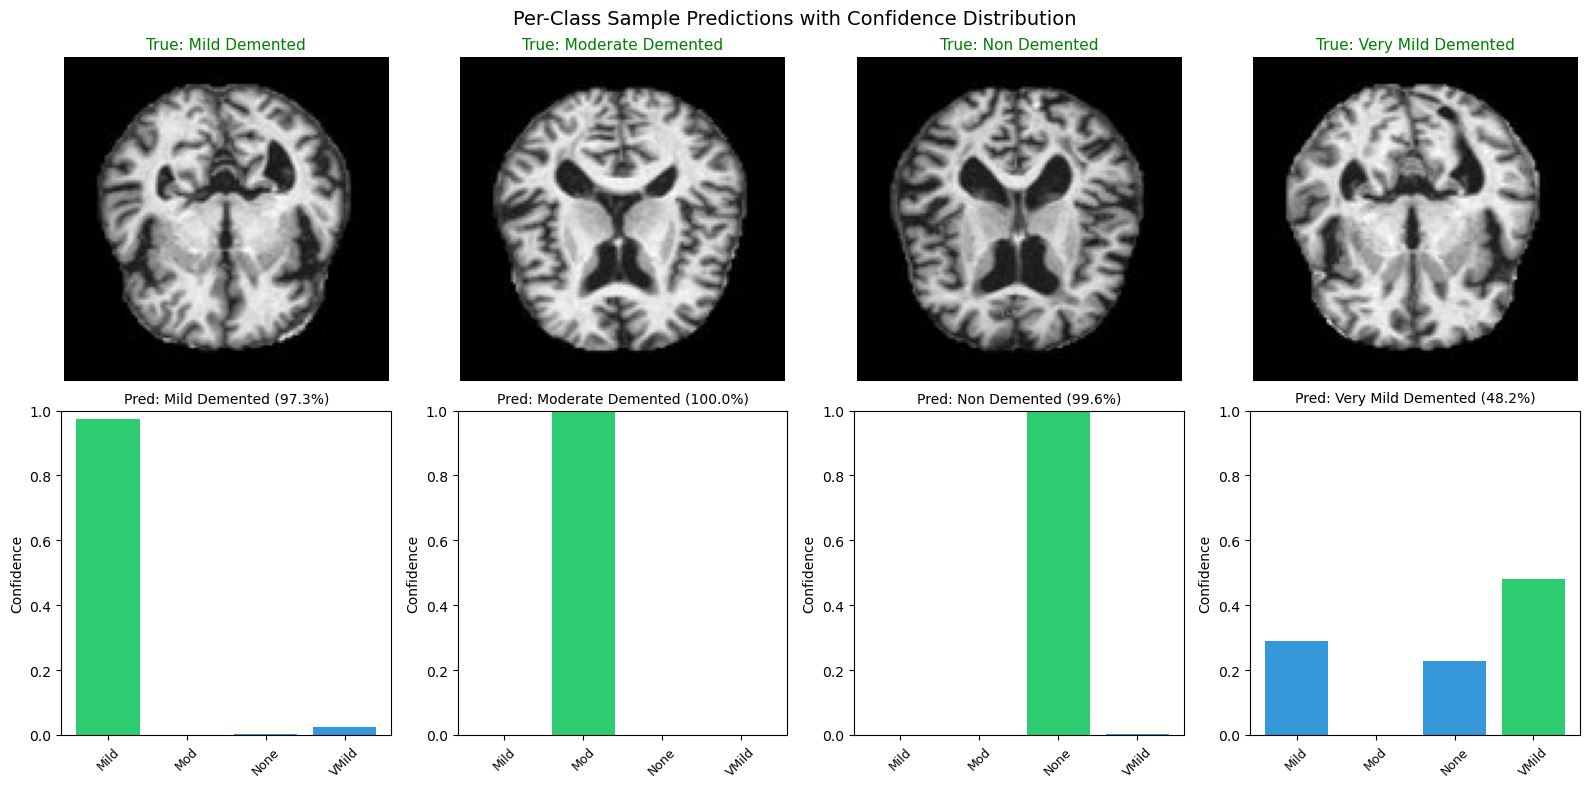

In [19]:
# Visualize one sample from each class with confidence distribution
def visualize_class_samples(model, dataset, indices, labels_map):
    """Show one sample from each class with prediction confidence."""
    model.eval()
    
    # Find one sample per class
    class_samples = {}
    for idx in indices:
        label = dataset[idx]['label']
        if label not in class_samples:
            class_samples[label] = idx
        if len(class_samples) == NUM_CLASSES:
            break
    
    fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 8))
    
    for i, (cls_id, real_idx) in enumerate(sorted(class_samples.items())):
        img = dataset[real_idx]['image']
        img_np = np.array(img, dtype=np.uint8)
        
        # Prepare and predict
        img_rgb = np.stack([img_np] * 3, axis=-1)
        processed = image_processor(images=img_rgb, return_tensors="pt")
        pixel_values = processed['pixel_values'].to(device)
        
        with torch.no_grad():
            outputs = model(pixel_values)
            probs = F.softmax(outputs.logits, dim=1)[0].cpu().numpy()
            pred_label = probs.argmax()
        
        # Top row: Image
        ax_img = axes[0, i]
        ax_img.imshow(img_np, cmap='gray')
        color = 'green' if pred_label == cls_id else 'red'
        ax_img.set_title(f"True: {labels_map[cls_id]}", fontsize=11, color=color)
        ax_img.axis('off')
        
        # Bottom row: Confidence bar chart
        ax_bar = axes[1, i]
        colors = ['#2ecc71' if j == pred_label else '#3498db' for j in range(NUM_CLASSES)]
        bars = ax_bar.bar(range(NUM_CLASSES), probs, color=colors)
        ax_bar.set_xticks(range(NUM_CLASSES))
        ax_bar.set_xticklabels(['Mild', 'Mod', 'None', 'VMild'], fontsize=9, rotation=45)
        ax_bar.set_ylim(0, 1)
        ax_bar.set_ylabel('Confidence')
        ax_bar.set_title(f"Pred: {labels_map[pred_label]} ({probs[pred_label]:.1%})", fontsize=10)
    
    plt.suptitle('Per-Class Sample Predictions with Confidence Distribution', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_class_samples(model, dataset, val_idx, LABELS)

## 8. Save Model

Save the trained model for later use or deployment.

In [20]:
# Save model and training results
import os
from datetime import datetime

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save model
model_path = 'models/swin_alzheimer_classifier.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_name': MODEL_NAME,
    'num_classes': NUM_CLASSES,
    'labels': LABELS,
    'metrics': metrics,
    'history': history,
    'training_config': {
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'epochs': len(history['train_loss']),
        'batch_size': BATCH_SIZE
    }
}, model_path)

print(f"✓ Model saved to: {model_path}")

# Save metrics summary
metrics_summary = {
    'model': 'Swin Transformer (microsoft/swin-base-patch4-window7-224)',
    'accuracy': metrics['accuracy'],
    'balanced_accuracy': metrics['balanced_accuracy'],
    'f1_macro': metrics['f1_macro'],
    'f1_weighted': metrics['f1_weighted'],
    'mcc': metrics['mcc'],
    'kappa': metrics['kappa'],
    'best_val_acc': max(history['val_acc']),
    'total_epochs': len(history['train_loss'])
}

print("\n📊 Final Model Summary:")
print("-" * 50)
for key, value in metrics_summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

✓ Model saved to: models/swin_alzheimer_classifier.pt

📊 Final Model Summary:
--------------------------------------------------
  model: Swin Transformer (microsoft/swin-base-patch4-window7-224)
  accuracy: 0.8760
  balanced_accuracy: 0.9044
  f1_macro: 0.8916
  f1_weighted: 0.8768
  mcc: 0.7996
  kappa: 0.7977
  best_val_acc: 0.8760
  total_epochs: 15


## 9. Summary

### Key Techniques Applied:
1. **Transfer Learning**: Fine-tuned Microsoft's Swin-Base Transformer pretrained on ImageNet
2. **Data Augmentation**: MONAI transforms with stronger augmentation for minority classes
3. **Class Imbalance Handling**:
   - Class-weighted CrossEntropyLoss
   - Balanced sampling with WeightedRandomSampler
4. **Training Optimization**:
   - Differential learning rates (higher for classifier head)
   - ReduceLROnPlateau scheduler
   - Early stopping to prevent overfitting
   - Gradient clipping for stability

### Swin Transformer Advantages:
- **Shifted Window Attention**: Efficient attention mechanism with linear complexity
- **Hierarchical Feature Maps**: Multi-scale representations suitable for medical imaging
- **Strong Pretrained Weights**: Leverages knowledge from large-scale image classification